In [1]:
#importing libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_excel('../dataset/online_course.xlsx')

In [4]:
df.head()

,user_id,course_id,course_name,instructor,course_duration_hours,certification_offered,difficulty_level,rating,enrollment_numbers,course_price,feedback_score,study_material_available,time_spent_hours,previous_courses_taken
0,15796,9366,Python for Beginners,Emma Harris,39.1,Yes,Beginner,5.0,21600,317.50,0.797,Yes,17.60,4
1,861,1928,Cybersecurity for Professionals,Alexander Young,36.3,Yes,Beginner,4.3,15379,40.99,0.770,Yes,28.97,9
2,38159,9541,DevOps and Continuous Deployment,Dr. Mia Walker,13.4,Yes,Beginner,3.9,6431,380.81,0.772,Yes,52.44,4
3,44733,3708,Project Management Fundamentals,Benjamin Lewis,58.3,Yes,Beginner,3.1,48245,342.80,0.969,No,22.29,6
4,11285,3361,Ethical Hacking Masterclass,Daniel White,30.8,Yes,Beginner,2.8,34556,381.01,0.555,Yes,22.01,5


In [5]:
df.tail()

,user_id,course_id,course_name,instructor,course_duration_hours,certification_offered,difficulty_level,rating,enrollment_numbers,course_price,feedback_score,study_material_available,time_spent_hours,previous_courses_taken
99995,10647,5466,Graphic Design with Canva,Emma Harris,17.3,Yes,Beginner,3.9,49101,485.34,0.838,Yes,16.35,3
99996,13800,2623,Stock Market and Trading Strategies,Dr. John Smith,68.4,Yes,Beginner,3.5,35107,162.80,0.922,Yes,41.94,7
99997,47131,1556,Networking and System Administration,Dr. John Smith,73.8,Yes,Beginner,4.3,12146,24.02,0.990,Yes,15.87,5
99998,49654,6001,Graphic Design with Canva,Daniel White,30.3,Yes,Beginner,3.5,9933,402.24,0.630,Yes,21.05,4
99999,12929,5763,Graphic Design with Canva,Daniel White,67.0,No,Beginner,2.3,3479,135.61,0.753,Yes,8.63,1


In [6]:
# checking DataFrame informations

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 14 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   user_id                   100000 non-null  int64  
 1   course_id                 100000 non-null  int64  
 2   course_name               100000 non-null  object 
 3   instructor                100000 non-null  object 
 4   course_duration_hours     100000 non-null  float64
 5   certification_offered     100000 non-null  object 
 6   difficulty_level          100000 non-null  object 
 7   rating                    100000 non-null  float64
 8   enrollment_numbers        100000 non-null  int64  
 9   course_price              100000 non-null  float64
 10  feedback_score            100000 non-null  float64
 11  study_material_available  100000 non-null  object 
 12  time_spent_hours          100000 non-null  float64
 13  previous_courses_taken    100000 non-null  in

In [8]:
df.describe()

,user_id,course_id,course_duration_hours,rating,enrollment_numbers,course_price,feedback_score,time_spent_hours,previous_courses_taken
count,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,24935.663570,5006.863560,52.38354,3.959859,25052.822850,261.073369,0.746865,20.691054,4.992670
std,14406.960108,2882.085456,27.42347,0.729958,14388.188356,139.013758,0.143683,13.669148,2.237259
min,1.000000,1.000000,5.00000,1.000000,50.000000,20.000000,0.092000,1.000000,0.000000
25%,12487.750000,2523.000000,28.60000,3.500000,12583.750000,140.100000,0.649000,9.900000,3.000000
50%,24793.500000,5012.000000,52.40000,4.000000,25057.500000,262.310000,0.750000,19.920000,5.000000
75%,37382.250000,7502.000000,76.10000,4.500000,37522.000000,381.702500,0.851000,30.080000,6.000000
max,49999.000000,9999.000000,100.00000,5.000000,49999.000000,500.000000,1.000000,84.150000,19.000000


In [9]:
# Finding Null values

In [10]:
df.isnull().sum()

user_id                     0
course_id                   0
course_name                 0
instructor                  0
course_duration_hours       0
certification_offered       0
difficulty_level            0
rating                      0
enrollment_numbers          0
course_price                0
feedback_score              0
study_material_available    0
time_spent_hours            0
previous_courses_taken      0
dtype: int64

In [11]:
# Drop Null Values if Exists

In [12]:
df.dropna(inplace=True)

In [13]:
# Count Duplicates

In [14]:
df.duplicated().sum()

0

In [15]:
# Seperate Object Columns for EDA

In [16]:
obj_cols = df.select_dtypes(include='object')

In [17]:
obj_cols.head(1)

,course_name,instructor,certification_offered,difficulty_level,study_material_available
0,Python for Beginners,Emma Harris,Yes,Beginner,Yes


In [18]:
# Checking for nulls

In [19]:
df[obj_cols.columns].isnull().sum()

course_name                 0
instructor                  0
certification_offered       0
difficulty_level            0
study_material_available    0
dtype: int64

In [20]:
# Number of Unique values in Object columns

In [21]:
for col in obj_cols:
    print(f"\n{col}")
    print(df[col].nunique())


course_name
20

instructor
20

certification_offered
2

difficulty_level
3

study_material_available
2


In [22]:
# Ploting the Object Columns to finding the majority between the features

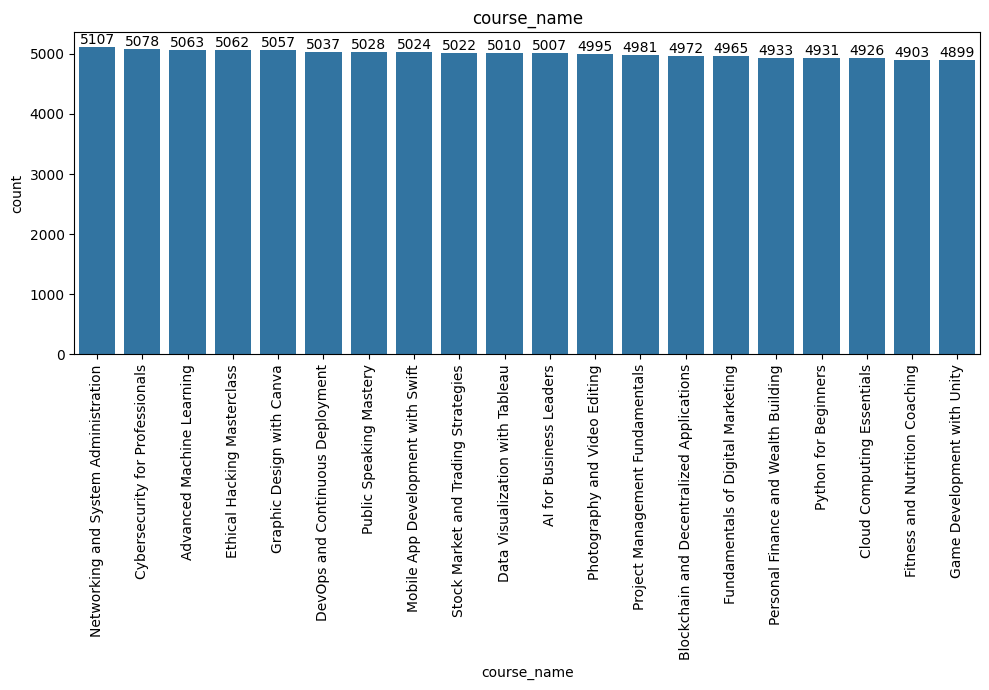

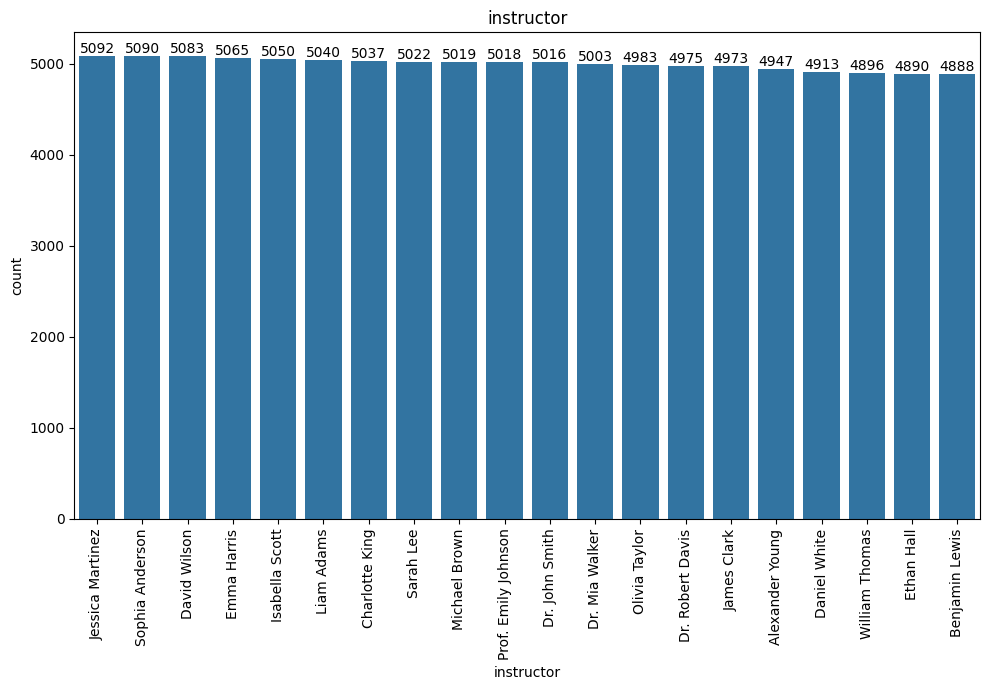

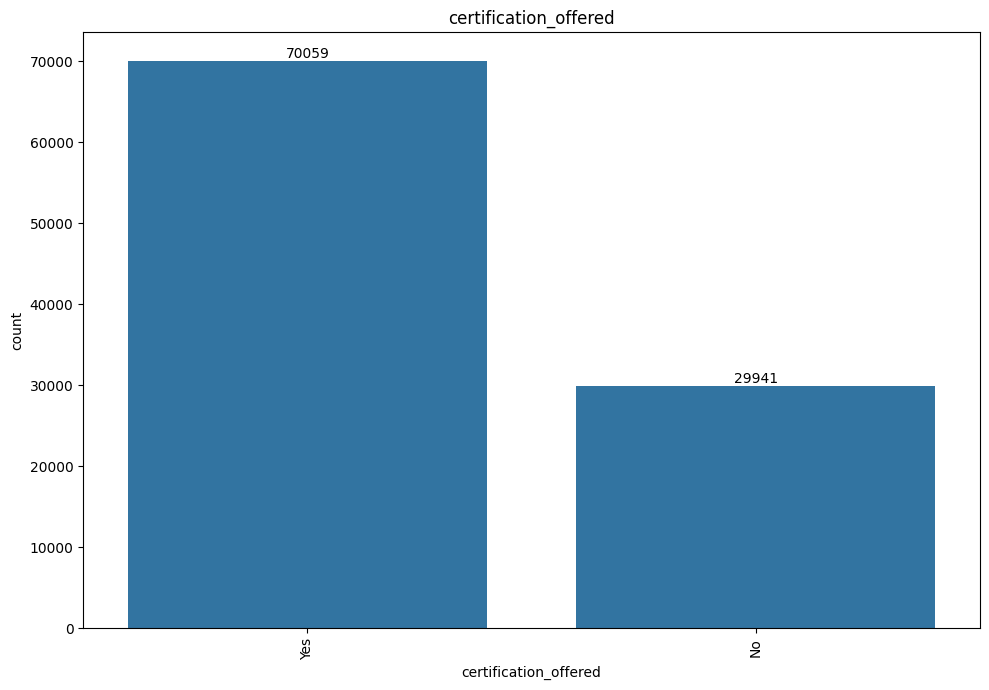

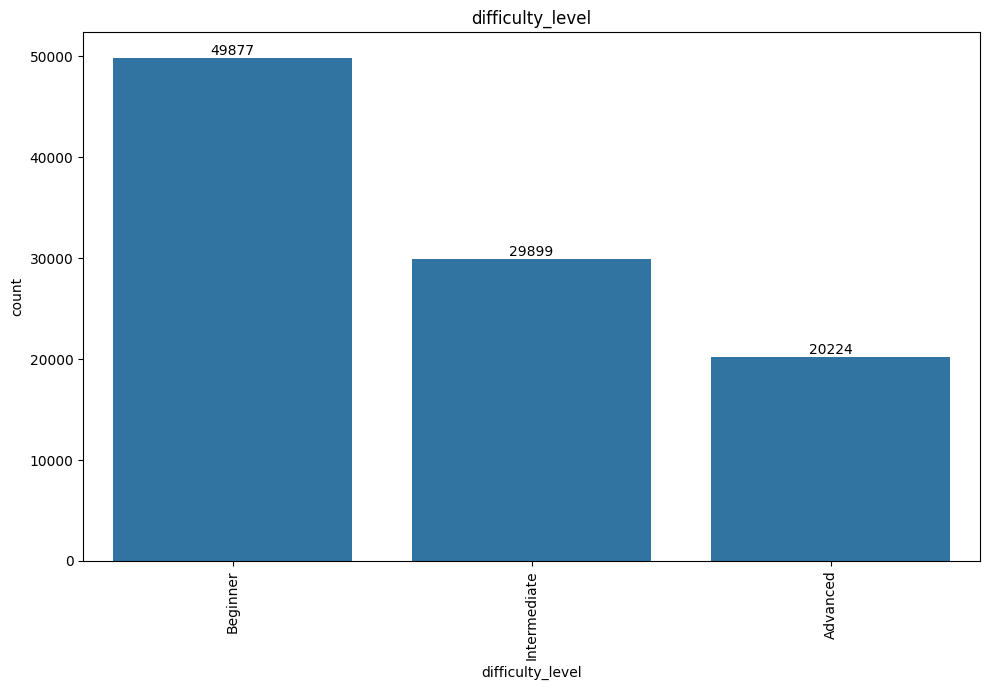

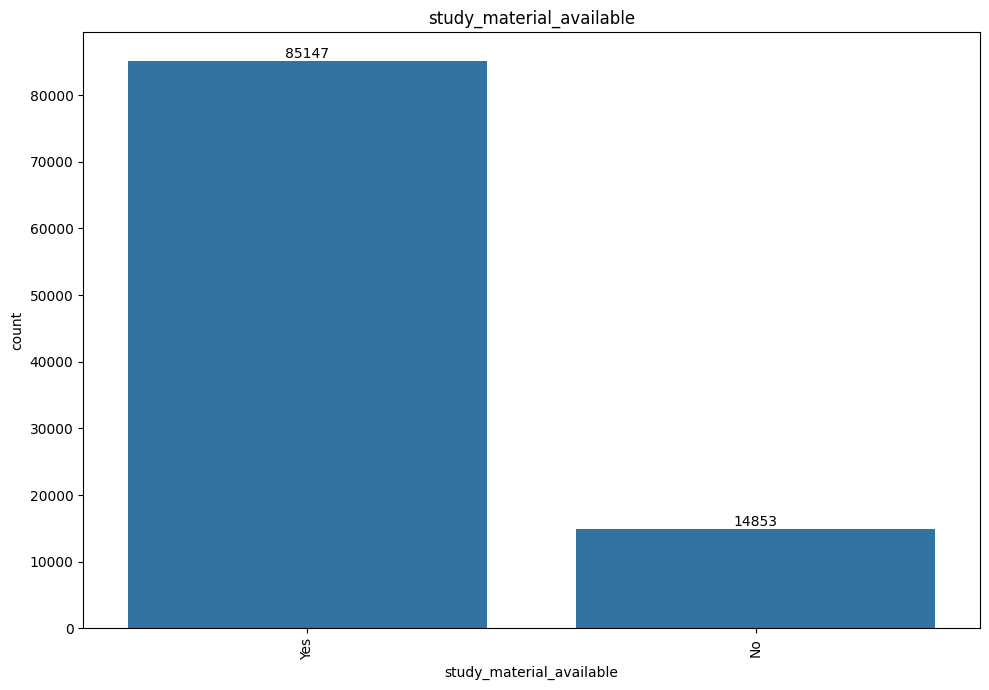

In [23]:
for col in obj_cols:
    plt.figure(figsize=(10, 7))

    ax = sns.countplot(
        data=df,
        x=col,
        order=df[col].value_counts().index
    )

    for container in ax.containers:
        ax.bar_label(container)

    plt.xticks(rotation=90)
    plt.title(col)
    plt.tight_layout()
    plt.show()

In [24]:
# how many unique users and uniques course

In [25]:
users_count = df['user_id'].nunique()
course_count = df['course_name'].nunique()

In [26]:
print(f'how many Unique users: {users_count}')
print(f'how many Unique courses: {course_count}')

how many Unique users: 43242
how many Unique courses: 20


In [27]:
# the user with more previous course taken

In [28]:
df.loc[df['previous_courses_taken'].idxmax()]

user_id                                                         41288
course_id                                                        1774
course_name                 Blockchain and Decentralized Applications
instructor                                                 Ethan Hall
course_duration_hours                                            64.3
certification_offered                                             Yes
difficulty_level                                             Beginner
rating                                                            4.9
enrollment_numbers                                              42049
course_price                                                   410.62
feedback_score                                                   0.83
study_material_available                                          Yes
time_spent_hours                                                28.11
previous_courses_taken                                             19
Name: 46093, dtype: 

In [29]:
# Seperate numerical columns

In [30]:
num_cols = df.select_dtypes(include=['int','float64'])
num_cols = num_cols.drop(columns=['user_id','course_id'], axis=1)

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 14 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   user_id                   100000 non-null  int64  
 1   course_id                 100000 non-null  int64  
 2   course_name               100000 non-null  object 
 3   instructor                100000 non-null  object 
 4   course_duration_hours     100000 non-null  float64
 5   certification_offered     100000 non-null  object 
 6   difficulty_level          100000 non-null  object 
 7   rating                    100000 non-null  float64
 8   enrollment_numbers        100000 non-null  int64  
 9   course_price              100000 non-null  float64
 10  feedback_score            100000 non-null  float64
 11  study_material_available  100000 non-null  object 
 12  time_spent_hours          100000 non-null  float64
 13  previous_courses_taken    100000 non-null  in

In [32]:
# checking that time_spent_hours by most of users 

<Axes: >

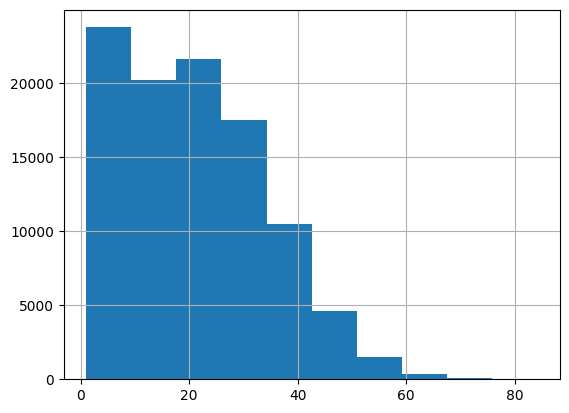

In [33]:
df['time_spent_hours'].hist()

In [34]:
# the most of the users given feedback above 4 point out of 10 

<Axes: >

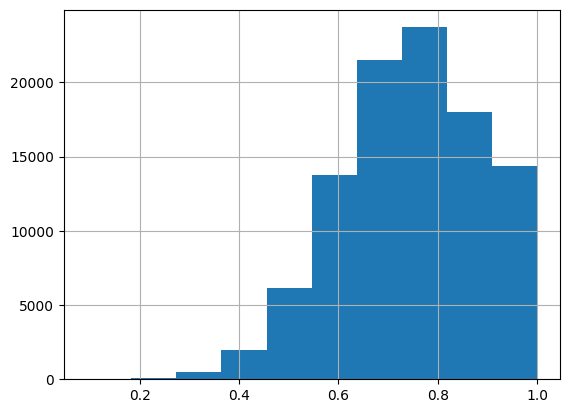

In [35]:
df['feedback_score'].hist()            

In [36]:
# ploting the rating feature

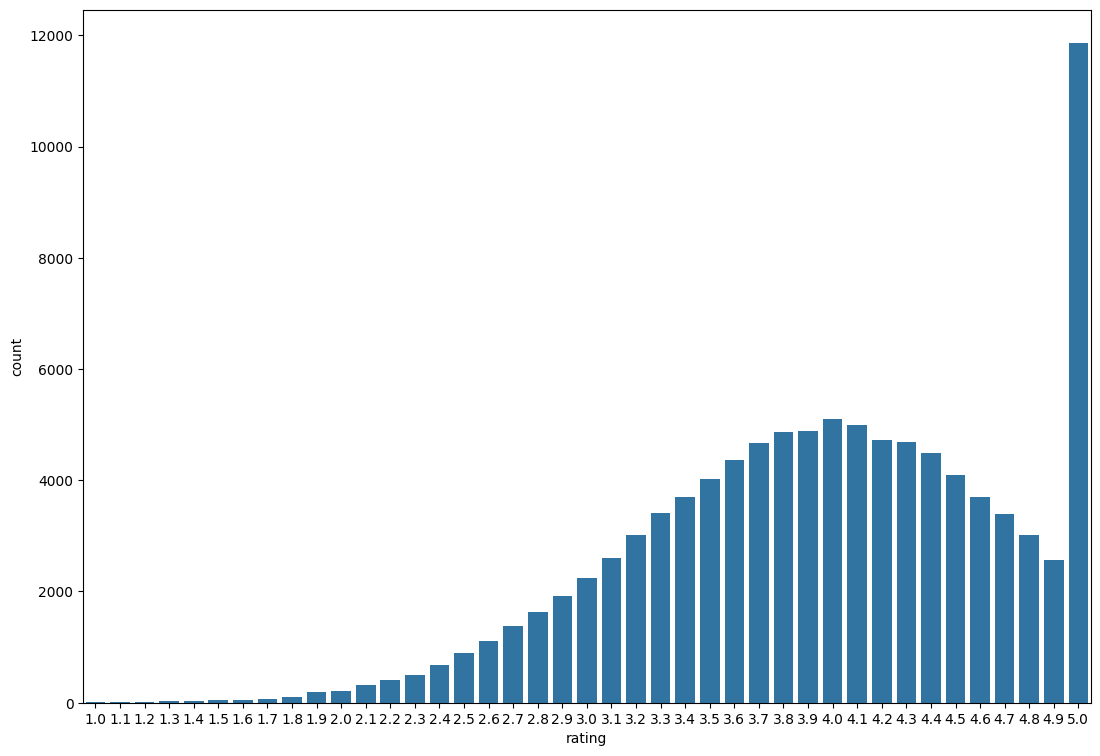

In [37]:
plt.figure(figsize=(13,9))
sns.countplot(data=df, x='rating')
plt.show()

In [38]:
num_cols.head()

,course_duration_hours,rating,enrollment_numbers,course_price,feedback_score,time_spent_hours,previous_courses_taken
0,39.1,5.0,21600,317.50,0.797,17.60,4
1,36.3,4.3,15379,40.99,0.770,28.97,9
2,13.4,3.9,6431,380.81,0.772,52.44,4
3,58.3,3.1,48245,342.80,0.969,22.29,6
4,30.8,2.8,34556,381.01,0.555,22.01,5


In [39]:
# Finding the Outliers

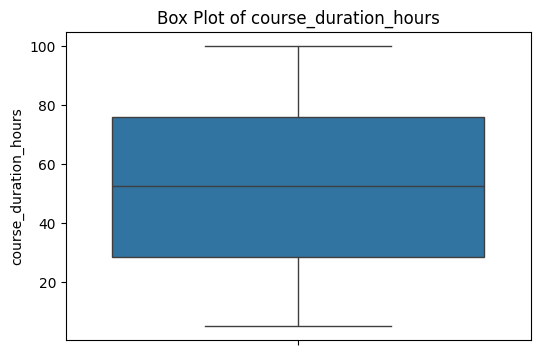

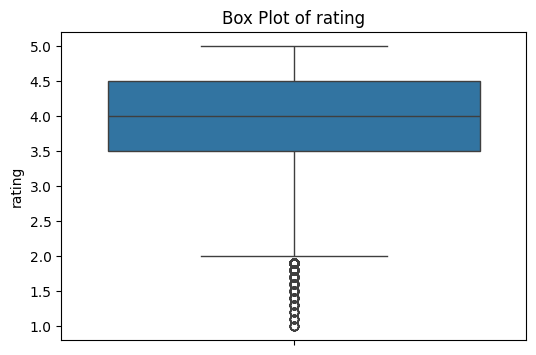

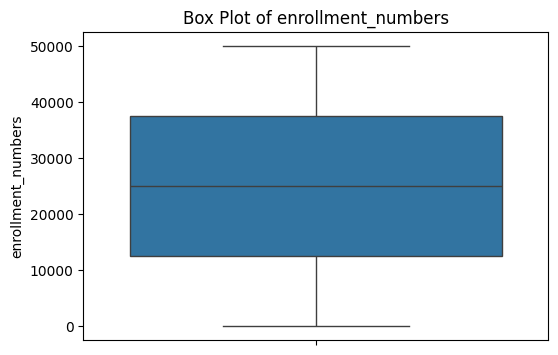

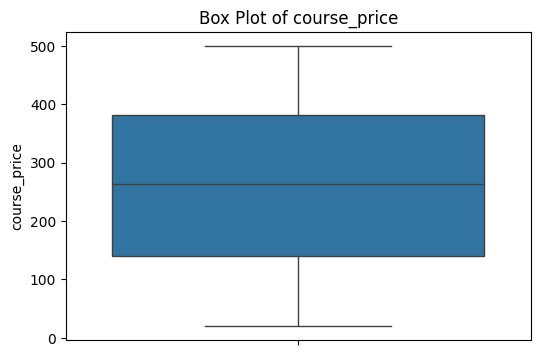

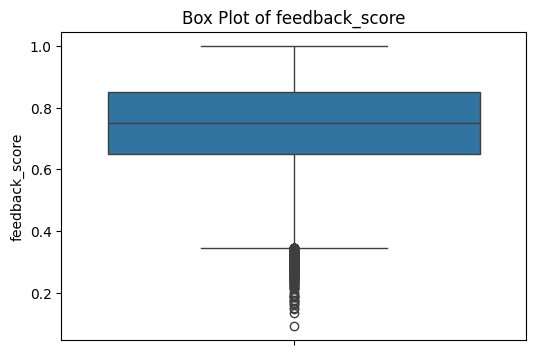

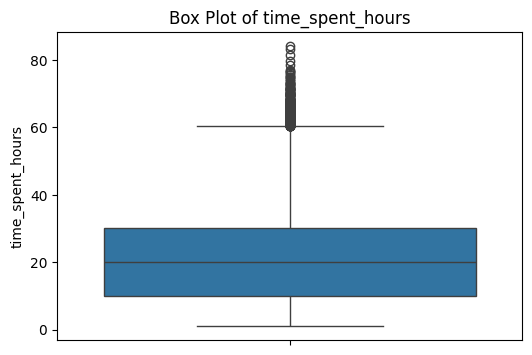

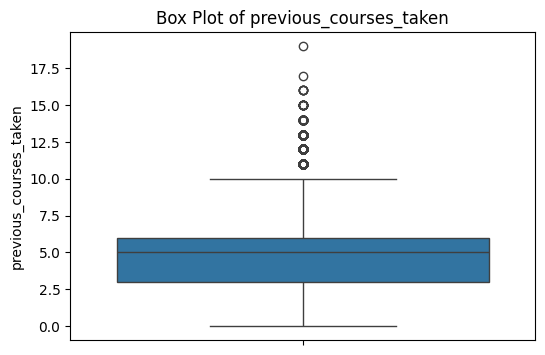

In [40]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=df, y=col)
    plt.title(f'Box Plot of {col}')
    plt.show()

In [41]:
#  Adjusting the outliers of the columns

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower) & (df[col] <= upper)]


In [42]:
# finding the Correlation between the numerical columns

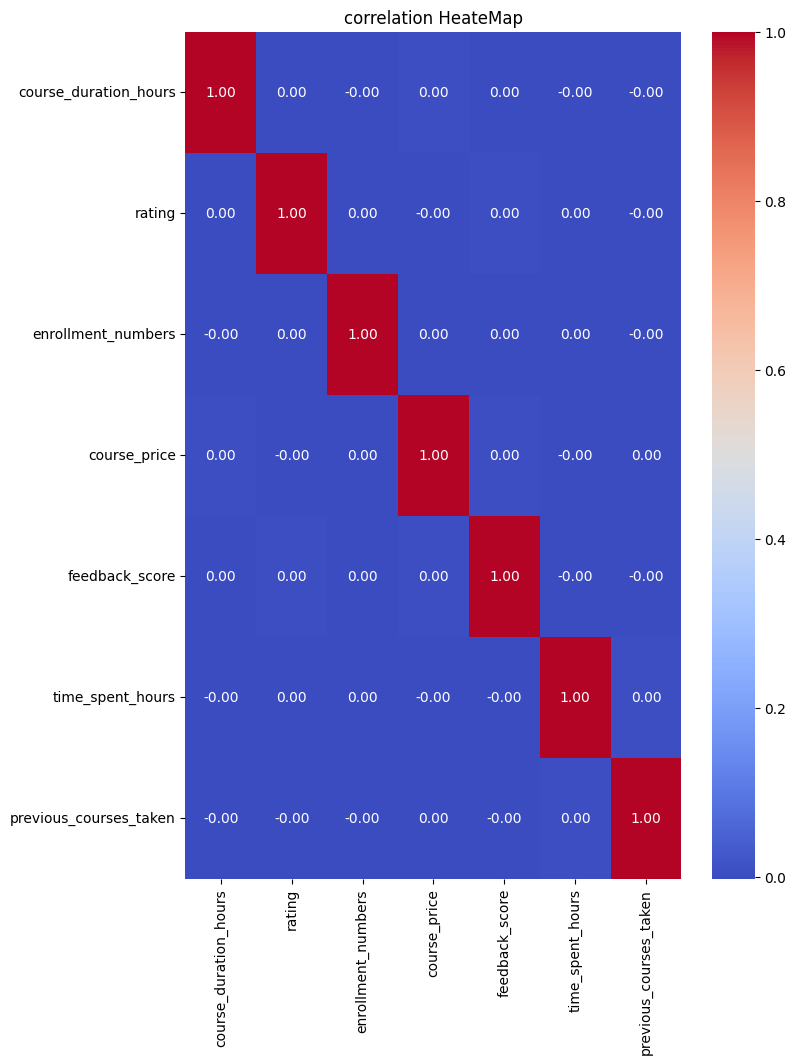

In [49]:
cor = df[num_cols.columns].corr()
plt.figure(figsize=(8,11))
sns.heatmap(cor,annot=True,cmap='coolwarm',fmt='.2f')
plt.title('correlation HeateMap')
plt.show()

In [44]:
corrmatrix = cor.unstack()

corrmatrix = corrmatrix[corrmatrix != 1]

corrmatrix = np.round(corrmatrix.sort_values(ascending=True),2)
                      
corrmatrix.head()

time_spent_hours       course_price             -0.0
course_price           time_spent_hours         -0.0
course_duration_hours  time_spent_hours         -0.0
time_spent_hours       course_duration_hours    -0.0
enrollment_numbers     previous_courses_taken   -0.0
dtype: float64

In [45]:
# There is no Coorelation between the features

In [46]:
df.to_csv("cleaned_dataset.csv",index=False)